In [ ]:
!pip install torchdiffeq torchsummary

In [ ]:
from cv2 import imread, resize
from numpy import sum, float32, sort,array
import random
from tqdm import tqdm
import os
from os import listdir

def total_files(directory):
    file_count = 0

    for root, dirs, files in os.walk(directory):
        file_count += len(files)

    return file_count


def shuffle_arrays(arrays, seed=42):
    random.seed(seed)
    zipped = list(zip(*arrays))
    random.shuffle(zipped)
    return zip(*zipped)


def get_sum(img_path):
    image = resize(imread(img_path, 0), (128, 128)).astype(float32)
    return sort(image)[:, ::-1][:,:60] / 256

def make_set(input,nr,d=3,seed=42):
    print("\n")
    total = total_files(input)
    print(total)
    random.seed(seed)
    fols = sorted(listdir(input))
    LEN = len(fols)
    freq,y = [],[]
    data = {}
    c=0
    with tqdm(total=total, unit="spectrogram", desc="Processing files") as pbar:
        for j in fols:
            rows, cols = [], []
            l = sorted(listdir(f"{input}/{j}"))
            data[j] = []
            for i in l:
                out = array(get_sum(f"{input}/{j}/{i}"))
                freq.append(out)
                y.append(c)
                data[j].append(out)
                pbar.update(1)
            c+=1
    return [array(freq),array(y),fols,data]

In [ ]:
inp = '/kaggle/input/3-gray-model/data/th/15/ffmpeg_gray_eys_15_th'
data={}
for fol in listdir(f"{inp}"):
    a = make_set(f"{inp}/{fol}/",False)
    data[fol] = a



1015


Processing files: 100%|██████████| 1015/1015 [00:07<00:00, 140.78spectrogram/s]




525


Processing files: 100%|██████████| 525/525 [00:03<00:00, 144.29spectrogram/s]




3563


Processing files: 100%|██████████| 3563/3563 [00:25<00:00, 138.11spectrogram/s]


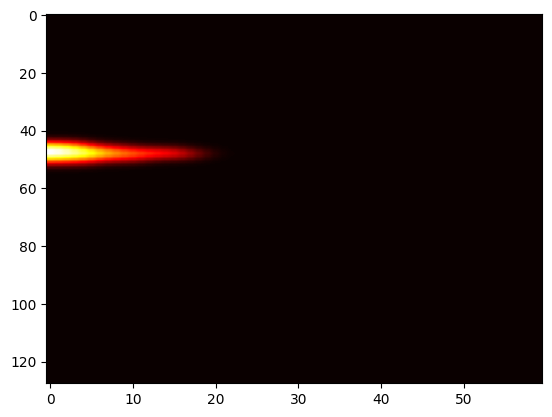

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.ndimage import gaussian_filter
mask = data['train'][0][9] > 0.08

plt.imshow(gaussian_filter(np.where(mask,  data['train'][0][9], 0),sigma=1.5), cmap='hot', aspect='auto')

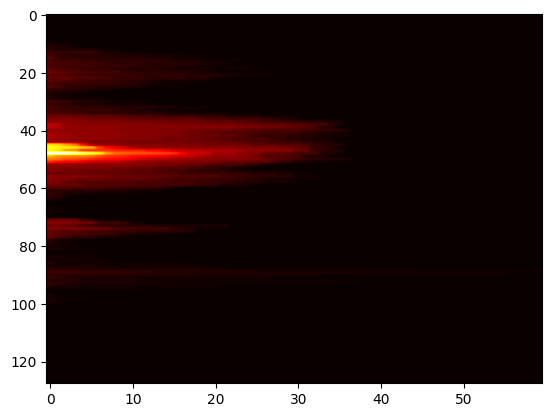

In [ ]:
plt.imshow(data['train'][0][9], cmap='hot', aspect='auto')

In [ ]:
from cv2 import imread, resize
from numpy import sum, float32, sort,array
import random
from tqdm import tqdm
from os import listdir,walk

def total_files(directory):
    file_count = 0
    for root, dirs, files in walk(directory):
        file_count += len(files)
    return file_count


def shuffle_arrays(arrays, seed=42):
    random.seed(seed)
    zipped = list(zip(*arrays))
    random.shuffle(zipped)
    return zip(*zipped)


def get_sum(img_path):
    image = resize(imread(img_path, 0), (128, 128)).astype(float32)
    return sum(image,axis=1) / (256*128)

def make_set(inp,seed=42):
    total = total_files(inp)
    print(total)
    random.seed(seed)
    fols = sorted(listdir(inp))
    LEN = len(fols)
    data = {}
    c=0
    with tqdm(total=total, unit="spectrogram", desc="Processing files") as pbar:
        for j in fols:
            rows, cols = [], []
            l = sorted(listdir(f"{inp}/{j}"))
            data[j] = []
            for i in l:
                out = get_sum(f"{inp}/{j}/{i}")
                data[j].append(out)
                pbar.update(1)
            data[j] = array(data[j])
            c+=1
    return data

In [ ]:
inp = '/kaggle/input/3-gray-model/data/th/15/ffmpeg_gray_eys_15_th'
data={}
for fol in listdir(f"{inp}"):
    a = make_set(f"{inp}/{fol}/",False)
    data[fol] = a

1015


Processing files: 100%|██████████| 1015/1015 [00:06<00:00, 156.31spectrogram/s]


525


Processing files: 100%|██████████| 525/525 [00:03<00:00, 158.77spectrogram/s]


3563


Processing files: 100%|██████████| 3563/3563 [00:24<00:00, 147.03spectrogram/s]


In [ ]:
unpack = {}
random.seed(42)
for key1,val1 in data['train'].items():
    unpack[key1] = {
        "main":[],"others":[]
    }
    for key2,val2 in data['train'].items():
        if key1==key2:
            unpack[key1]['main'] = val2
        else:
            for i in val2:
                unpack[key1]['others'].append(i)

In [ ]:
for key,val in unpack.items():
    print(key,len(val['main']))

Blue Jay 230
Common Chiffchaff 362
Common Cuckoo 196
Common Nightingale 176
Common Redstart 203
Common blackbird 166
Eurasian Eagle-Owl 305
Eurasian Hoopoe 212
Eurasian Skylark 225
European Robin 212
Great Tit 287
Mallard 194
Red-wattled Lapwing 333
Western Wood-Pewee 217
Yellowhammer 245


In [ ]:
from numpy import append
dat = {}
for key,val in unpack.items():
    dat[key] = {}
    dat[key]['freq']=list(val['main'])
    dat[key]['labels'] = [1.0 for i in range(len(val['main']))]
    for i in val['others'][:len(val['main'])]:
        dat[key]['freq'].append(i)
    for i in range(len(val['main'])):
        dat[key]['labels'].append(0.0)

In [ ]:
for key,val in unpack.items():
    random.seed(42)
    random.shuffle(dat[key]['freq'])
    random.shuffle(dat[key]['labels'])

    dat[key]['freq']   = array(dat[key]['freq'])
    dat[key]['labels'] = array(dat[key]['labels'])

In [ ]:
import torch
import pytorch_lightning as pl
from torchdiffeq import odeint_adjoint as odeint
import torch.nn.functional as F


In [ ]:
from torch.utils.data import Dataset, DataLoader

datasets={}

device  = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

class EasyLoder(Dataset):
    def __init__(self, x, y, device):
        self.x = torch.from_numpy(x).to(device, dtype=torch.float32)
        self.y = torch.from_numpy(y).to(device, dtype=torch.long)

    def __len__(self):
        return len(self.x)

    def __getitem__(self, idx):
        return self.x[idx], self.y[idx]

for key,val in dat.items():
    datasets[key] = {}
    dataset        = EasyLoder(val['freq'], val['labels'], device)
    dataloader     = DataLoader(dataset, shuffle=True, batch_size=256)
    out = []
    for image, label in dataloader:
        batch_size,freq= image.shape
        u0           = torch.zeros(batch_size,freq,60).to(device)
        u0[:, :, 0]  = image
        out.append([u0,label])

    datasets[key]['dataset'] = out

In [ ]:
from math import pi, ceil,exp

def precompute_gaussian_kernel(kernel_size, sigma):
    if kernel_size % 2 == 0:
        raise ValueError("Kernel size must be odd")

    mean = kernel_size // 2
    x = torch.arange(kernel_size, dtype=torch.float32, device=device)
    y = torch.arange(kernel_size, dtype=torch.float32, device=device)
    X, Y = torch.meshgrid(x, y, indexing='ij')
    kernel = (1 / (2 * pi * sigma ** 2)) * torch.exp(-((X - mean) ** 2 + (Y - mean) ** 2) / (2 * sigma ** 2))
    kernel /= kernel.sum()
    return kernel.unsqueeze(0).unsqueeze(0)

class GaussianFilter(pl.LightningModule):
    def __init__(self, sigma_list, mode='reflect'):
        super(GaussianFilter, self).__init__()
        self.mode = mode
        self.sigma_list = sigma_list
        self.kernel_dict = {}
        for sigma in sigma_list:
            kernel_size = max(1, int(2 * ceil(3 * sigma) + 1))
            if kernel_size % 2 == 0:
                kernel_size += 1
            kernel = precompute_gaussian_kernel(kernel_size, sigma).to(device)
            self.kernel_dict[sigma] = kernel
        self.current_sigma = sigma_list[0]

    def set_sigma_by_index(self, index):
        if index < 0 or index >= len(self.sigma_list):
            raise IndexError(f"Index {index} is out of bounds for sigma list of length {len(self.sigma_list)}")
        self.current_sigma = self.sigma_list[index]

    def forward(self, input_tensor):
        batch_size, height, width = input_tensor.shape
        input_tensor = input_tensor.unsqueeze(1)
        kernel = self.kernel_dict[self.current_sigma]
        pad_width = kernel.shape[-1] // 2
        if self.mode == 'reflect':
            padded_input = F.pad(input_tensor, (pad_width,) * 4, mode='reflect')
        elif self.mode == 'constant':
            padded_input = F.pad(input_tensor, (pad_width,) * 4, mode='constant', value=0)
        elif self.mode == 'nearest':
            padded_input = F.pad(input_tensor, (pad_width,) * 4, mode='replicate')
        else:
            raise ValueError("Unsupported padding mode")
        output = F.conv2d(padded_input, kernel, groups=1)
        return output.squeeze(1)

In [ ]:
class Heat_Eq_PDE(torch.nn.Module):
    def __init__(self,dx,num_freqs):
        super(Heat_Eq_PDE, self).__init__()
        self.alpha      = torch.nn.Parameter(torch.ones(num_freqs) * 0.1)
        self.Q0         = torch.nn.Parameter(torch.ones(num_freqs) * 1)
        self.lamb       = torch.nn.Parameter(torch.ones(num_freqs) * 0.001)
        self.dx         = dx

    def Q(self, t):
        return self.Q0[:, None] * torch.exp(t * -self.lamb[:, None])

    def laplace_FDM(self, u, delta): # Finate Diffrence Method (Center )
        u = torch.nn.functional.pad(u, (1, 1),mode='replicate')
        #∂²u/∂x² ≈ (u[i+1] - 2*u[i] + u[i-1]) / (h²) (why 2 ? cuz i+1 > bounds and i-1 < bounds)
        du = (u[:,:,2:] - 2*u[:,:,1:-1] + u[:,:,:-2]) / (delta**2)
#         du       = torch.nan_to_num(du, nan=0.0)
        return du

    def forward(self,t,u):
        u           = self.alpha[:, None] * u
        du2_dx2     = self.laplace_FDM(u, self.dx) # d/dt (ux) = dx/dt * u
        du_dt       = du2_dx2 + self.Q(t)
        return du_dt

In [ ]:
class HeatODE(pl.LightningModule):
    def __init__(self, ode_params={},input_shape = [128,60],num_classes=15):
        super(HeatODE, self).__init__()
        self.time          = torch.linspace(ode_params['time']['min'], ode_params['time']['max'], steps = ode_params['time']['time_steps'])
        self.dt            = self.time[1] - self.time[0]
        self.dx            = ode_params['dx']
        self.rtol          = ode_params['sol']['rtol']
        self.atol          = ode_params['sol']['atol']
        self.method        = ode_params['sol']['method']

        self.heat_model    = Heat_Eq_PDE(self.dx, input_shape[0])
        self.weight        = torch.nn.Parameter(torch.randn(input_shape[1],input_shape[0]))


    def forward(self, u0):
        solutions = []
#         self.guss_filter.set_sigma_by_index(2)
        solution = odeint(
            self.heat_model,
            u0,
            self.time,
            rtol=self.rtol, atol=self.atol, method=self.method
        )[-1]  # @ t=n
        solution = solution @ self.weight
        solution = torch.sum(solution,dim=0)
        return solution


ode_params = {
    "time": {
        "min": 0.0, "max": 1.0, "time_steps": 60
    },
    "dx": 0.1,
    "sol": {
        "rtol": 1e-5,
        "atol": 1e-12,
        "method": "rk4"
    },
    "sigmas": [0.5,1.0,1.5,2.0,2.5]
}


model   = HeatODE(ode_params=ode_params).to(device)

In [ ]:
torch.cuda.empty_cache()

In [ ]:
image, label = datasets['Blue Jay']['dataset'][0]
output  = model(image)
print(output)

tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 

tensor([0.0032, 0.0053, 0.0043, 0.0050, 0.0033, 0.0031, 0.0046, 0.0028, 0.0052,
        0.0034, 0.0031, 0.0038, 0.0037, 0.0052, 0.0051, 0.0017, 0.0060, 0.0035,
        0.0038, 0.0029, 0.0033, 0.0039, 0.0036, 0.0038, 0.0033, 0.0016, 0.0058,
        0.0036, 0.0027, 0.0036, 0.0031, 0.0044, 0.0019, 0.0027, 0.0035, 0.0043,
        0.0043, 0.0043, 0.0021, 0.0041, 0.0045, 0.0062, 0.0042, 0.0025, 0.0013,
        0.0029, 0.0053, 0.0054, 0.0032, 0.0042, 0.0038, 0.0042, 0.0043, 0.0039,
        0.0025, 0.0046, 0.0046, 0.0054, 0.0046, 0.0040, 0.0020, 0.0038, 0.0024,
        0.0040, 0.0040, 0.0035, 0.0054, 0.0054, 0.0048, 0.0032, 0.0040, 0.0052,
        0.0033, 0.0058, 0.0031, 0.0035, 0.0031, 0.0041, 0.0039, 0.0053, 0.0046,
        0.0044, 0.0033, 0.0030, 0.0021, 0.0046, 0.0033, 0.0040, 0.0045, 0.0042,
        0.0024, 0.0038, 0.0037, 0.0046, 0.0036, 0.0026, 0.0028, 0.0053, 0.0045,
        0.0036, 0.0041, 0.0032, 0.0053, 0.0028, 0.0034, 0.0031, 0.0027, 0.0044,
        0.0043, 0.0040, 0.0046, 0.0030, 

In [ ]:
print(model.weight.grad)

Parameter containing:
tensor([[ 7.5780e-01, -1.0738e+00, -1.9229e+00,  ...,  1.0345e+00,
          7.4391e-01, -9.4028e-01],
        [ 3.0279e-02,  1.6947e-01, -1.3495e+00,  ...,  9.1387e-02,
          1.1836e+00, -1.8611e-02],
        [ 1.6992e-01,  1.3005e+00, -4.7844e-01,  ..., -1.2180e+00,
         -1.7501e-02, -7.6280e-02],
        ...,
        [-1.0691e+00,  3.1370e-01, -7.0550e-01,  ...,  2.5257e-01,
          1.3487e+00,  6.3203e-01],
        [ 1.6088e-03, -1.2797e-02, -8.3150e-01,  ...,  1.0423e+00,
         -4.9092e-01,  4.3690e-01],
        [-7.6584e-01, -1.4737e+00, -1.2352e+00,  ...,  5.9174e-01,
         -1.7912e+00, -1.6097e-01]], device='cuda:0', requires_grad=True)


In [ ]:
LOSS    = criterion(output,label)
LOSS.backward()
optimizer.step()

In [ ]:
print()

In [ ]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.1)
criterion = torch.nn.CrossEntropyLoss()

In [ ]:
from time import time
acc,loss,t=0,0,0
def train(dataset,epoch,num_epochs):
    train_bar = tqdm(dataset, desc=f'Epoch {epoch+1}/{num_epochs}')
    for image, label in train_bar:
        s = time()
        optimizer.zero_grad()
        output  = model(image)
        LOSS    = criterion(output,label)
        LOSS.backward()
        optimizer.step()
        acc   = ((torch.argmax(output,dim=1)==label).sum()/batch_size).cpu().numpy()
        loss  = LOSS.detach().cpu().numpy()
        train_bar.set_postfix(train_loss=loss/c, train_acc=acc/c)
        e = time()
        t += e-s
        c+=1
    return acc/c,loss/c,t

In [ ]:
def format_time(seconds):
    hours = int(seconds // 3600)
    minutes = int((seconds % 3600) // 60)
    seconds = int(seconds % 60)
    return f'{hours:02d}:{minutes:02d}:{seconds:02d}'

In [ ]:
num_epochs=50
total =0
for i in range(num_epochs):
    a,l,t = train(datasets['train']['dataset'],i,num_epochs)
    print('\n',a,l,format_time((num_epochs-i)*t))

Epoch 1/50:   0%|          | 0/14 [00:00<?, ?it/s]


RuntimeError: size mismatch, got input (32768), mat (32768x60), vec (128)

In [ ]:
torch.cuda.empty_cache()
torch.cuda.synchronize()

In [ ]:
y=k[8][0].detach().cpu().numpy()
#

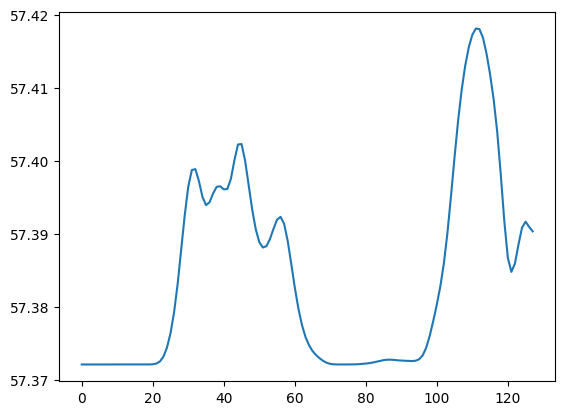

In [ ]:
from numpy import sum
plt.plot(sum(y,axis=1))

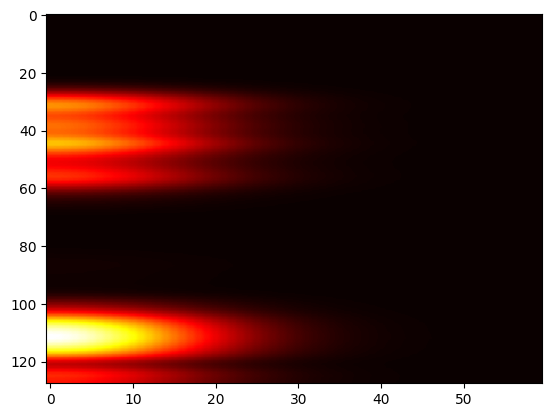

In [ ]:
plt.imshow(y, cmap='hot', aspect='auto')

In [ ]:
birds={}
for i in datasets['train']['labels']:
    birds[i] = []
c=0
y=0
for a, b in datasets['train']['dataset']:
    out = model(a)
    out = out[-1].detach().cpu().numpy()
    for i in range(len(b)):
        birds[datasets['train']['labels'][b[i]]].append(out[i])
        c=+1
    print(y*100/15)
    y+=1

0.0
6.666666666666667
13.333333333333334
20.0
26.666666666666668
33.333333333333336
40.0
46.666666666666664
53.333333333333336
60.0
66.66666666666667
73.33333333333333
80.0
86.66666666666667
93.33333333333333
100.0
106.66666666666667
113.33333333333333
120.0
126.66666666666667
133.33333333333334
140.0
146.66666666666666
153.33333333333334
160.0
166.66666666666666
173.33333333333334
180.0


In [ ]:
from os import makedirs
import numpy as np
from scipy.ndimage import zoom
makedirs("/kaggle/working/heats",exist_ok=True)
t = 0
for bird,val in birds.items():
    makedirs(f"/kaggle/working/heats/{bird}",exist_ok=True)
    for img in val:
        resized_arr = zoom(img, (128 / img.shape[0], 128 / img.shape[1]), order=1)
        plt.imsave(f"/kaggle/working/heats/{bird}/{t}.png",resized_arr, cmap='hot')
        t+=1

In [ ]:
for i in birds.keys():
    mkdir(f"/kaggle/working/heats/{i}")
    print(birds[i].shape)
    for n in range(len(birds[i][-1])):

    c+=1
    print((c*(n+1))/(15*128))

In [ ]:
c=0
birds={}
for bird,dataloder in datasets['train'].items():
    birds[bird] = {}
    for batch in dataloder:
        output = model(batch)
#         plt.imshow(output[-1][i], cmap='hot', aspect='auto')
#         plt.title(label[i])
        birds[bird] = output.cpu().detach().numpy()
        break
    print(c*100/15)
    c+=1

In [ ]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.1)
criterion = torch.nn.CrossEntropyLoss()

In [ ]:
def train(dataset,epoch,num_epochs):
    acc,loss,t,c=0,0,0,1
    train_bar = tqdm(dataset, desc=f'Epoch {epoch+1}/{num_epochs}')
    for image, label in train_bar:
        s = time()
        optimizer.zero_grad()
        output  = model(image)
        LOSS    = criterion(output,label)
        LOSS.backward()
        optimizer.step()
        acc   += ((torch.argmax(output,dim=1)==label).sum()/256).cpu().numpy()
        loss  += LOSS.detach().cpu().numpy()
        train_bar.set_postfix(train_loss=loss/c, train_acc=acc/c)

        e = time()
        t += e-s
        c+=1
    return acc/c,loss/c,t

In [ ]:
def format_time(seconds):
    hours = int(seconds // 3600)
    minutes = int((seconds % 3600) // 60)
    seconds = int(seconds % 60)
    return f'{hours:02d}:{minutes:02d}:{seconds:02d}'

In [ ]:
from time import time
num_epochs=50
total =0
for i in range(num_epochs):
    acc,loss,t = train(datasets['train']['dataset'],i,num_epochs)
    print(acc,loss,format_time((num_epochs-i)*t))

In [ ]:
%rm -rf  /kaggle/working/heats
%rm /kaggle/working/a.zip

rm: cannot remove '/kaggle/working/a.zip': No such file or directory


In [ ]:
!zip -r a.zip /kaggle/working/heats

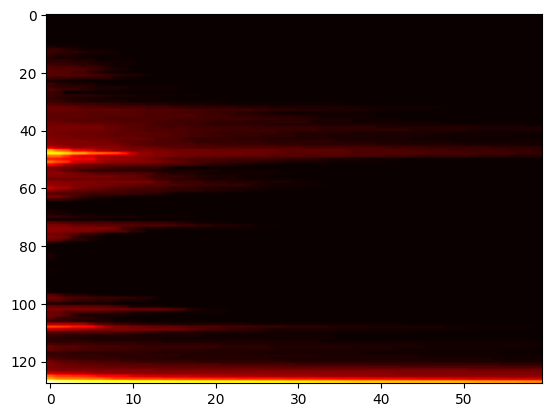

In [ ]:
plt.imshow(data['train'][3]['Blue Jay'][7], cmap='hot', aspect='auto')

In [ ]:
from os import mkdir
import numpy as np
from scipy.ndimage import zoom
c=0
mkdir("/kaggle/working/heats")
for i in birds.keys():
    mkdir(f"/kaggle/working/heats/{i}")
    print(birds[i].shape)
    for n in range(len(birds[i][-1])):
        arr = birds[i][-1][n]
        resized_arr = zoom(arr, (128 / arr.shape[0], 128 / arr.shape[1]), order=1)
        plt.imsave(f"/kaggle/working/heats/{i}/{n}.png",resized_arr, cmap='hot')
    c+=1
    print((c*(n+1))/(15*128))

(15, 128, 128, 60)
0.06666666666666667
(15, 128, 128, 60)
0.13333333333333333
(15, 128, 128, 60)
0.2
(15, 128, 128, 60)
0.26666666666666666
(15, 128, 128, 60)
0.3333333333333333
(15, 128, 128, 60)
0.4
(15, 128, 128, 60)
0.4666666666666667
(15, 128, 128, 60)
0.5333333333333333
(15, 128, 128, 60)
0.6
(15, 128, 128, 60)
0.6666666666666666
(15, 128, 128, 60)
0.7333333333333333
(15, 128, 128, 60)
0.8
(15, 128, 128, 60)
0.8666666666666667
(15, 128, 128, 60)
0.9333333333333333
(15, 128, 128, 60)
1.0
